# This Notebook is used to create a visual representation of the camera trajectories

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import PIL
import json
from PIL import Image

In [32]:
poses=[]

for i in range(0,370,1):
    filename = filename=f"/home/adam/Desktop/CurrentBranch/src/main/src/vtr_db_extractor/odom_poses/odom__{i:04d}.txt"
    matrix = []
    with open(filename, 'r') as file:
        for line in file:
            # Skip empty lines
            if line.strip() and not line.startswith('u'):
                # Split the line by whitespace and convert each element to float
                row = [float(val) for val in line.strip().split()]
                matrix.append(row)
    temp = np.array(matrix[0:4])
    poses.append(np.array(matrix[0:4]))
poses=np.array(poses)

[[ 0.00000e+00  0.00000e+00  0.00000e+00]
 [ 2.73328e-04  1.06246e-04 -1.28941e-05]
 [ 8.77263e-05  1.47879e-05 -9.13194e-05]
 ...
 [-3.00080e+00  5.88471e+00 -5.73746e-01]
 [-3.01705e+00  5.88533e+00 -5.72007e-01]
 [-3.03422e+00  5.88615e+00 -5.70214e-01]]


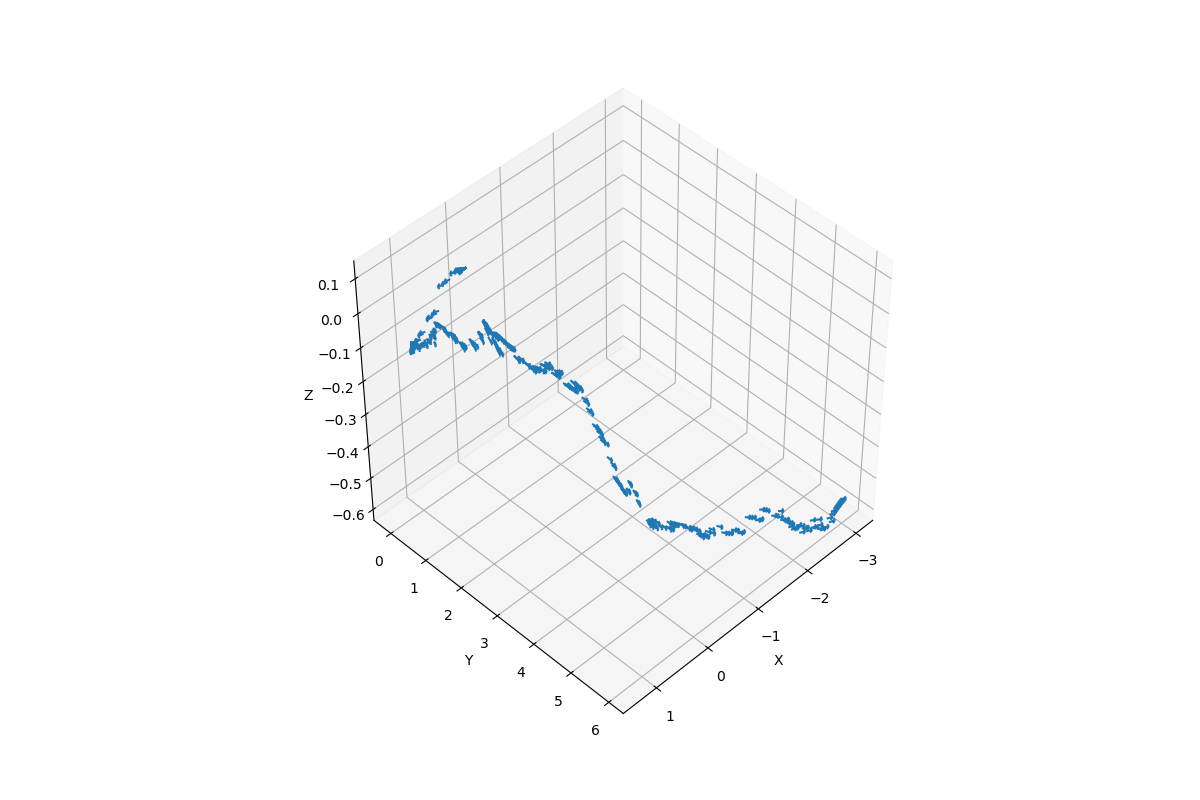

In [33]:
%matplotlib ipympl
origins = poses[:, :3, -1]
dirs = np.stack([np.sum([1, 0, 0] * pose[:3, :3], axis=-1) for pose in poses])
print(origins)

ax = plt.figure(figsize=(12, 8)).add_subplot(projection='3d')
_ = ax.quiver(
  origins[..., 0].flatten(),
  origins[..., 1].flatten(),
  origins[..., 2].flatten(),
  dirs[..., 0].flatten(),
  dirs[..., 1].flatten(),
  dirs[..., 2].flatten(), length=0.1, normalize=True)
ax.set_box_aspect([1,1,1])
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.view_init(45, 45) 
plt.show()

<class 'numpy.ndarray'>


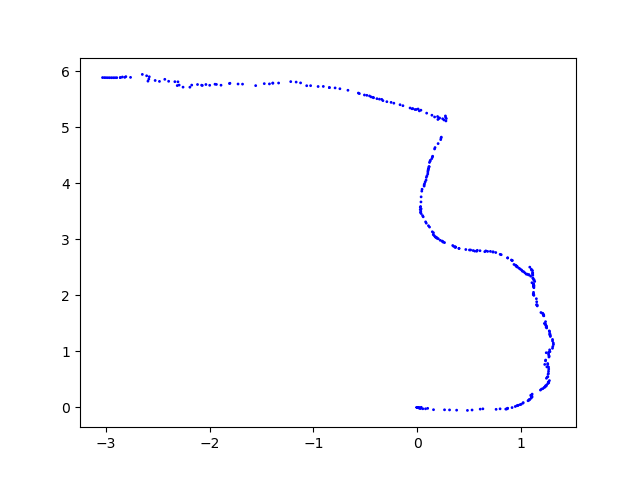

In [34]:
%matplotlib ipympl
x= origins[..., 0].flatten()
y= origins[..., 1].flatten()
z= origins[..., 2].flatten()
#print(np.array(x))
print(type(x))
s = np.ones(len(x))
#plt.scatter(x=x, y=y, color='red')
plt.scatter(x, y, s=s, color='blue', label='Group 1')
plt.show()

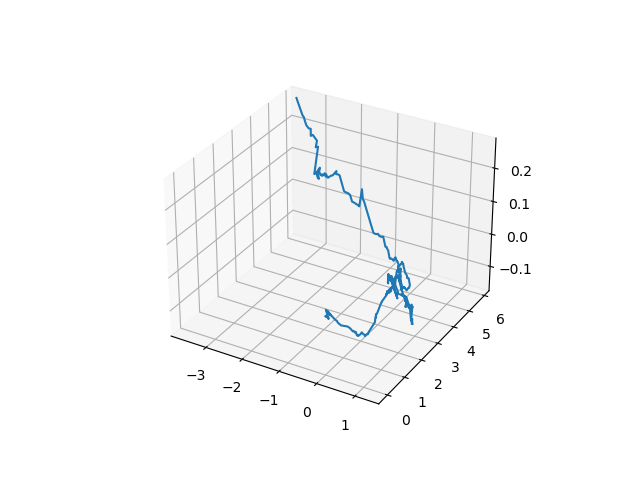

In [31]:

%matplotlib ipympl
ax = plt.axes(projection='3d')
ax.plot3D(x, y, z)